In [1]:
from google.colab import files
upload=files.upload()

Saving IRIS.csv to IRIS.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('IRIS.csv')

In [4]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
143,6.8,3.2,5.9,2.3,Iris-virginica
75,6.6,3.0,4.4,1.4,Iris-versicolor
55,5.7,2.8,4.5,1.3,Iris-versicolor
114,5.8,2.8,5.1,2.4,Iris-virginica
124,6.7,3.3,5.7,2.1,Iris-virginica


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [8]:
nums_col=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors=['red','green','grey','purple']

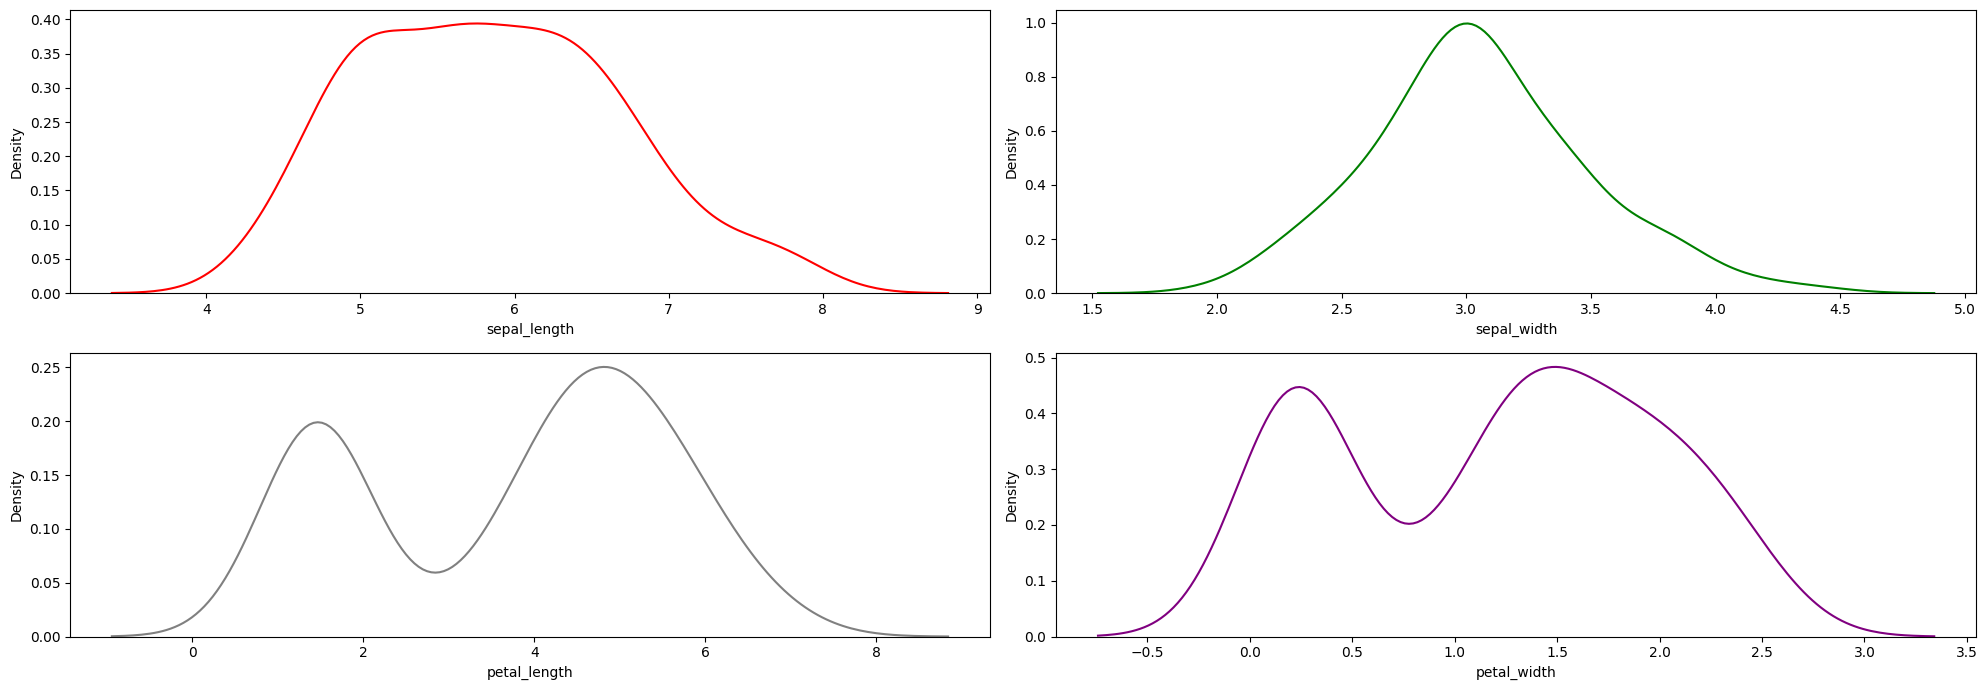

In [9]:
fig,axes=plt.subplots(2,2,figsize=(20,7))

axes=axes.flatten()
for i,col in enumerate(nums_col):
  sns.kdeplot(data=df,x=df[col],ax=axes[i],color=colors[i])
plt.tight_layout()
plt.show()

####**The KDE plots show that sepal features are roughly symmetric, while petal features are multimodal due to species differences. Since there is no severe skewness, power transformation is not required for these features. The petal features actually provide useful discriminative information for classification tasks.**

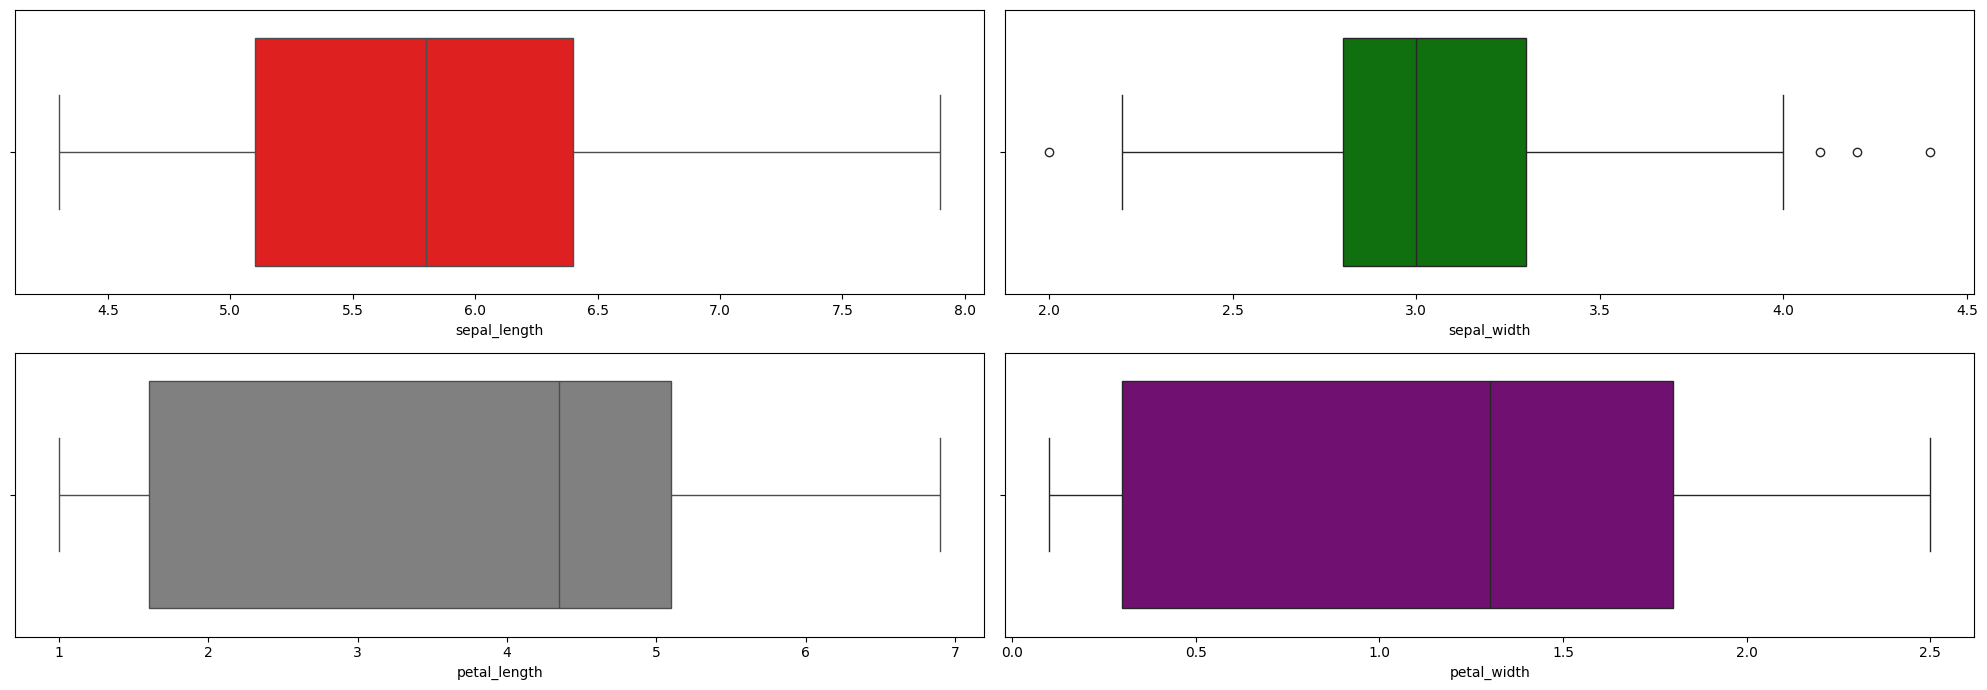

In [10]:
fig,axes=plt.subplots(2,2,figsize=(20,7))

axes=axes.flatten()
for i,col in enumerate(nums_col):
  sns.boxplot(data=df,x=df[col],ax=axes[i],color=colors[i])
plt.tight_layout()
plt.show()

**NO SUCH OURLIERS**

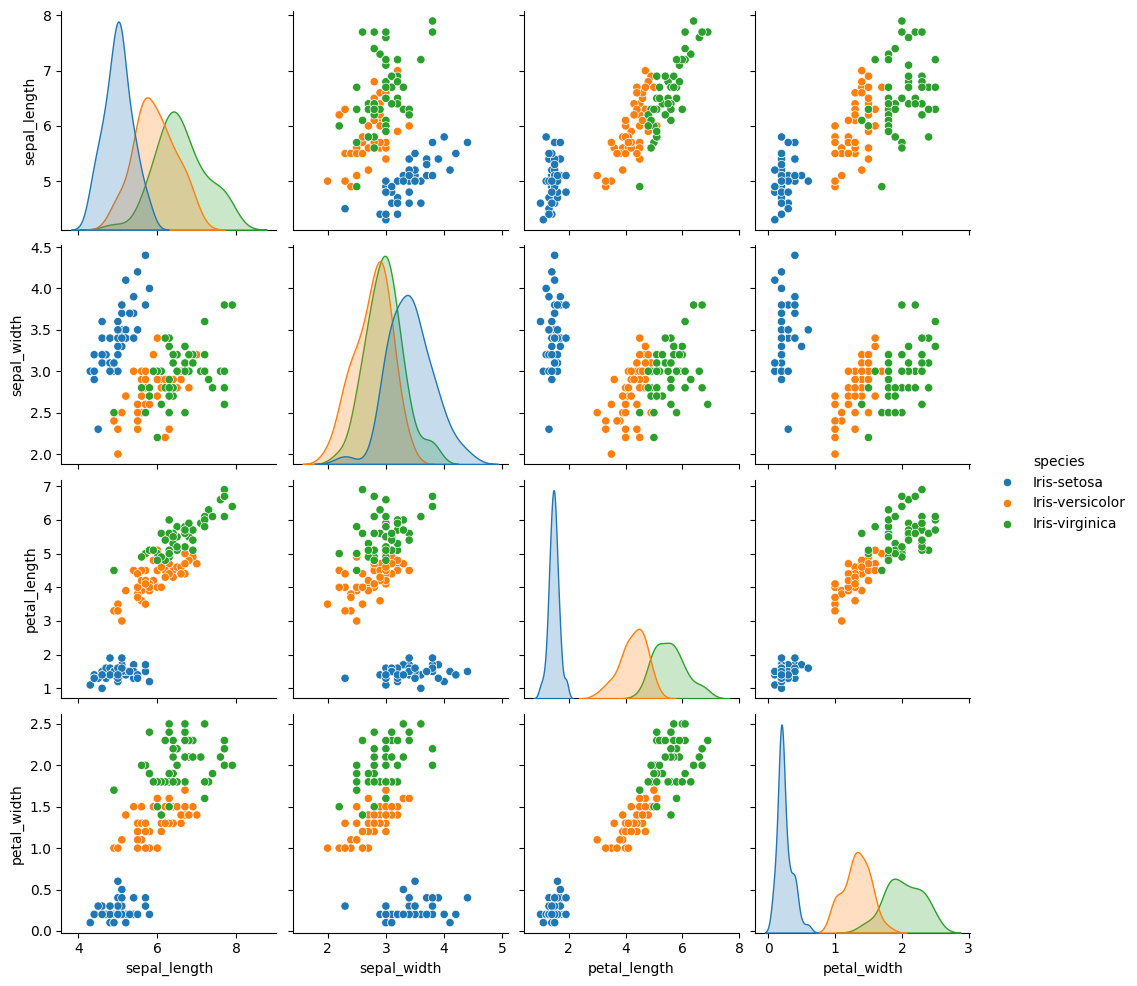

In [11]:
sns.pairplot(df,hue='species')

([<matplotlib.patches.Wedge at 0x7efc812c62a0>,
 [Text(0.5499999722395388, 0.9526279601903919, 'Iris-setosa'),
  Text(-1.0999999999999959, -9.616505800409723e-08, 'Iris-versicolor'),
  Text(0.5500003659264657, -0.9526277328950455, 'Iris-virginica')],
 [Text(0.29999998485793017, 0.5196152510129409, '33.3%'),
  Text(-0.5999999999999978, -5.2453668002234845e-08, '33.3%'),
  Text(0.30000019959625396, -0.5196151270336611, '33.3%')])

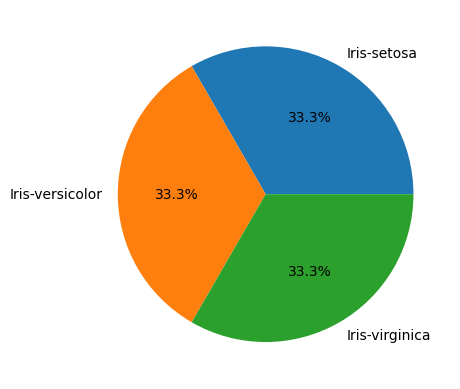

In [12]:
plt.pie(df['species'].value_counts(),labels=df['species'].value_counts().index,autopct='%1.1f%%')

**DATA PERFECTLY BALANCED**

<Axes: >

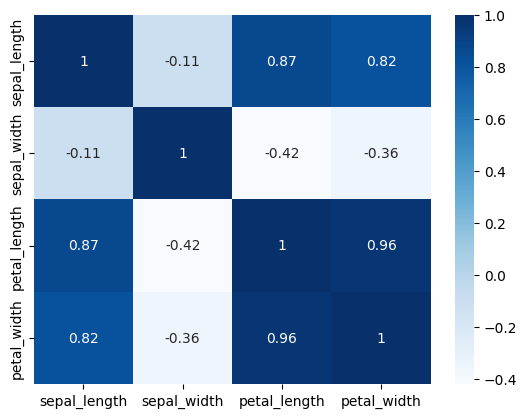

In [13]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Blues')

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.pipeline import Pipeline


from sklearn.preprocessing import StandardScaler,LabelEncoder


from sklearn.linear_model import LogisticRegression


from sklearn.metrics import accuracy_score, classification_report

In [15]:
df['species']=LabelEncoder().fit_transform(df['species'])

In [16]:
x=df.drop('species',axis=1)
y=df['species']

In [17]:
x_train , x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [18]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [19]:
df.iloc[70]

,70
sepal_length,5.9
sepal_width,3.2
petal_length,4.8
petal_width,1.8
species,1.0


In [20]:

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(105, 4)
(45, 4)
(105,)
(45,)


In [27]:
num_pipe_lg=Pipeline([
    ('scaler',StandardScaler()),
    ('lg',LogisticRegression(max_iter=1000))

])

In [28]:
params_grid_lg=[
    {
        'lg__penalty':['l2'],
        'lg__solver': ['lbfgs'],
        'lg__C': [0.1,0.3,0.5,0.7,1,5,10],

    },
      {

        'lg__penalty':['l2'],
        'lg__solver':['liblinear'],
        'lg__C': [0.1,0.3,0.5,0.7,1,10],

    },
      {
        'lg__penalty':['l2'],
        'lg__solver': ['saga'],
        'lg__C': [0.1,0.3,0.5,0.7,1,10],

    },
     {
        'lg__penalty':['l1'],
        'lg__solver': ['liblinear'],
        'lg__C': [0.1,0.3,0.5,0.7,1,10],

    },
      {
        'lg__penalty':['l1'],
        'lg__solver': ['saga'],
        'lg__C': [0.1,0.3,0.5,0.7,1,10],

    },
      {
        'lg__penalty':['elasticnet'],
        'lg__solver': ['saga'],
        'lg__C': [0.1,0.3, 0.5,0.8,1,5],
        'lg__l1_ratio': [0.2, 0.5,0.7,0.4],

    }
]

In [29]:
grid_lg=GridSearchCV(
    estimator=num_pipe_lg,
    param_grid=params_grid_lg,
    cv=5,
    scoring='r2'

)

In [30]:

import traceback


In [31]:
try:
  best_estiamtor_lg=grid_lg.fit(x_train,y_train)
except Exception as e:
  print(e)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [33]:
print(best_estiamtor_lg.best_estimator_)
print(best_estiamtor_lg.best_score_)
print(best_estiamtor_lg.best_params_)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lg',
                 LogisticRegression(C=1, l1_ratio=0.5, max_iter=1000,
                                    penalty='elasticnet', solver='saga'))])
0.9249079976818313
{'lg__C': 1, 'lg__l1_ratio': 0.5, 'lg__penalty': 'elasticnet', 'lg__solver': 'saga'}


In [34]:
y_pred_lg=best_estiamtor_lg.predict(x_test)
print(pd.DataFrame(classification_report(y_test,y_pred_lg,output_dict=True)))

              0     1     2  accuracy  macro avg  weighted avg
precision   1.0   1.0   1.0       1.0        1.0           1.0
recall      1.0   1.0   1.0       1.0        1.0           1.0
f1-score    1.0   1.0   1.0       1.0        1.0           1.0
support    19.0  13.0  13.0       1.0       45.0          45.0


# LOGISTICREGRESSION SCORE:92%![image.png](The model used is Logistic Regression with Elastic Net regularization (penalty='elasticnet', l1_ratio=0.5, solver='saga') inside a pipeline with StandardScaler.

The model achieved:

Accuracy ≈ 92.49% (cross-validation / training phase)

Test classification report shows 100% precision, recall, and F1-score for all classes (0,1,2)

Interpretation:

Perfect test performance (1.0 scores) indicates very strong class separation in the dataset.

Since this is the Iris dataset, such near-perfect results are expected because it is well-structured and easily separable.

In [35]:
df.columns


Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [38]:
sepal_length=float(input("Enter sepal length: "))
sepal_width=float(input("Enter sepal width:"))

petal_length=float(input("Enter petal length:"))
petal_width=float(input("Enter petal width:"))


Enter sepal length: 1
Enter sepal width:1
Enter petal length:1
Enter petal width:1


In [39]:

user_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

In [40]:
prediction=best_estiamtor_lg.predict(user_data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [41]:
labels = ['setosa', 'versicolor', 'virginica']
print("Flower is:", labels[prediction[0]])

Flower is: setosa
